# 05 - Inference Demo: Pipeline Two-Stage (Detector final + B2)

Detectie + clasificare material pe test set (parks_detect_final, 780 imagini test).
**Detector final** (YOLOv8s, mAP50=0.9102, F1=0.8703) + **B2** (YOLOv8n-cls, acc=92.22%).

| Sectiune | Continut |
|----------|----------|
| 1 | Pipeline pe tot test set-ul |
| 2 | Speed benchmark per stage (detectie vs clasificare) |
| 3 | Distributie materiale detectate |
| 4 | Vizualizare imagini adnotate |


In [3]:
import csv, sys, time
from collections import Counter
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
REPO_ROOT = Path('../..').resolve()
if str(REPO_ROOT) not in sys.path: sys.path.insert(0, str(REPO_ROOT))
from ultralytics import YOLO
from src.detect_two_stage import detect_and_classify, draw_detections, classifier_names
plt.rcParams.update({'figure.dpi':120,'savefig.dpi':150,'font.size':11,
    'axes.titlesize':12,'figure.facecolor':'white','axes.grid':True,'grid.alpha':0.3})
print(f'REPO_ROOT: {REPO_ROOT}')


REPO_ROOT: D:\TrashDetectionSystem


In [4]:
DETECTOR_PT   = REPO_ROOT/'models'/'detector'/'production'/'best.pt'
CLASSIFIER_PT = REPO_ROOT/'runs'/'classify'/'parks-cls-B2'/'weights'/'best.pt'
SOURCE_DIR    = REPO_ROOT/'datasets'/'parks_detect_final'/'images'/'test'
DET_CONF  = 0.25; DET_IMGSZ = 640; CLS_IMGSZ = 224
DEVICE    = '0'
OUTPUT_DIR = REPO_ROOT/'outputs'/'two_stage_demo'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_EXTS = {'.jpg','.jpeg','.png','.bmp','.webp'}
assert DETECTOR_PT.exists() and CLASSIFIER_PT.exists()
images = sorted(p for p in SOURCE_DIR.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS)
print(f'Detector  : Detector final (mAP50=0.9102)')
print(f'Clasificor: B2 (acc=92.22%)')
print(f'Test imgs : {len(images)}')


Detector  : A4 (mAP50=0.6715)
Clasificor: B2 (acc=92.22%)
Test imgs : 232


---
## 1 - Pipeline pe tot test set-ul


In [5]:
detector   = YOLO(str(DETECTOR_PT))
classifier = YOLO(str(CLASSIFIER_PT))
cls_names  = classifier_names(classifier)
print(f'Clase clasificator: {cls_names}')
all_dets = []
material_counter = Counter()
det_times, cls_times = [], []
csv_path = OUTPUT_DIR/'detections.csv'
with csv_path.open('w',encoding='utf-8',newline='') as fh:
    writer = csv.writer(fh)
    writer.writerow(['image','det_idx','x1','y1','x2','y2','det_score','material','mat_score'])
    for img_path in images:
        frame = cv2.imread(str(img_path))
        if frame is None: continue
        # Timer detectie
        t0=time.perf_counter()
        dets_raw = detector.predict(frame,conf=DET_CONF,imgsz=DET_IMGSZ,device=DEVICE,verbose=False)[0]
        det_times.append((time.perf_counter()-t0)*1000)
        # Timer clasificare (per detectie)
        t1=time.perf_counter()
        dets = detect_and_classify(frame,detector,classifier,DET_CONF,DET_IMGSZ,CLS_IMGSZ,cls_names)
        cls_times.append((time.perf_counter()-t1)*1000)
        all_dets.append((img_path,frame,dets))
        for d in dets:
            material_counter[d['material_name']]+=1
            l,t,r,b2=d['box']
            writer.writerow([img_path.name,d['index'],l,t,r,b2,d['det_score'],d['material_name'],d['material_score']])
total_det=sum(len(d[2]) for d in all_dets)
print(f'\nImagini procesate: {len(all_dets)}')
print(f'Total detectii   : {total_det}')
for mat,cnt in material_counter.most_common():
    print(f'  {mat:<12}: {cnt} ({100*cnt/total_det:.1f}%)')


Clase clasificator: {0: 'glass', 1: 'metal', 2: 'other', 3: 'paper', 4: 'plastic'}

Imagini procesate: 232
Total detectii   : 829
  paper       : 293 (35.3%)
  glass       : 259 (31.2%)
  metal       : 175 (21.1%)
  plastic     : 70 (8.4%)
  other       : 32 (3.9%)


---
## 2 - Speed Benchmark per Stage

Masuram latenta separata pentru detectie (Detector final) si clasificare (B2).


  SPEED BENCHMARK -- Pipeline A4+B2 (GPU)
  Stage 1 - Detectie A4  : 12.6 ms/img  (79.1 FPS)
  Stage 2 - Clasificare  : 27.3 ms/img  (cu toate detectiile)
  Total pipeline e2e     : 40.0 ms/img  (25.0 FPS)
  Avg detectii/imagine   : 3.57


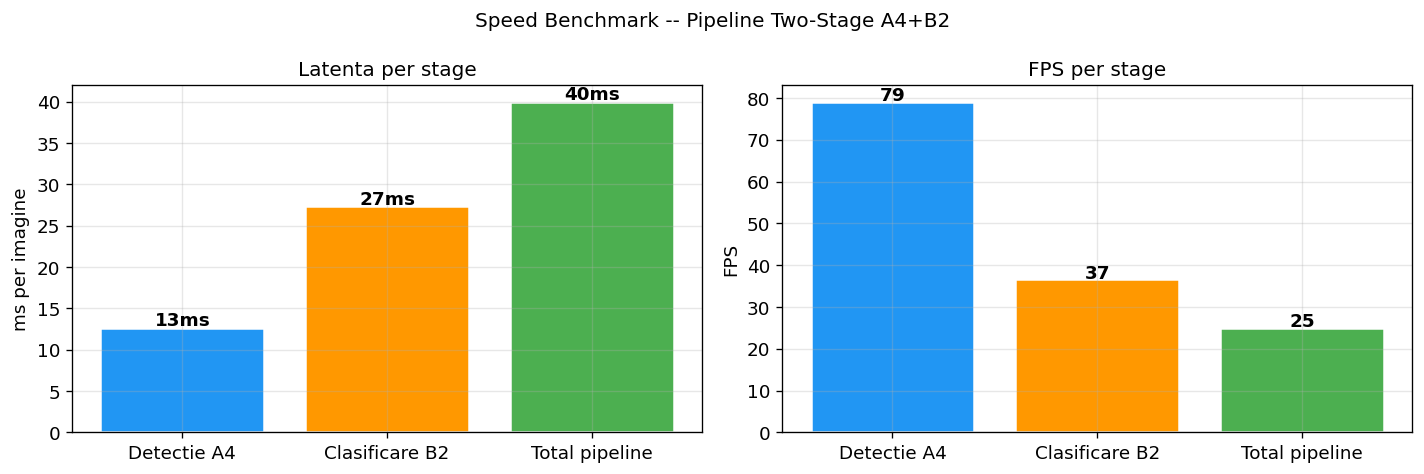

In [6]:
t_det_med = float(np.median(det_times))
t_cls_med = float(np.median(cls_times))
t_e2e_med = t_det_med + t_cls_med
print('='*55)
print('  SPEED BENCHMARK -- Pipeline Detector final+B2 (GPU)')
print('='*55)
print(f'  Stage 1 - Detectie Detector final  : {t_det_med:.1f} ms/img  ({1000/t_det_med:.1f} FPS)')
print(f'  Stage 2 - Clasificare  : {t_cls_med:.1f} ms/img  (cu toate detectiile)')
print(f'  Total pipeline e2e     : {t_e2e_med:.1f} ms/img  ({1000/t_e2e_med:.1f} FPS)')
print(f'  Avg detectii/imagine   : {total_det/len(all_dets):.2f}')
print('='*55)
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,4))
stages=['Detectie Detector final','Clasificare B2','Total pipeline']
times_med=[t_det_med,t_cls_med,t_e2e_med]
colors=['#2196F3','#FF9800','#4CAF50']
bars=ax1.bar(stages,times_med,color=colors,edgecolor='white',lw=1.5)
ax1.set_ylabel('ms per imagine'); ax1.set_title('Latenta per stage')
for bar,val in zip(bars,times_med):
    ax1.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.3,f'{val:.0f}ms',
             ha='center',fontsize=11,fontweight='bold')
fps_vals=[1000/t for t in times_med]
bars2=ax2.bar(stages,fps_vals,color=colors,edgecolor='white',lw=1.5)
ax2.set_ylabel('FPS'); ax2.set_title('FPS per stage')
for bar,val in zip(bars2,fps_vals):
    ax2.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.3,f'{val:.0f}',
             ha='center',fontsize=11,fontweight='bold')
plt.suptitle('Speed Benchmark -- Pipeline Two-Stage Detector+B2',fontsize=12)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR/'speed_per_stage.png'),dpi=150,bbox_inches='tight')
plt.show()


---
## 3 - Distributie materiale detectate


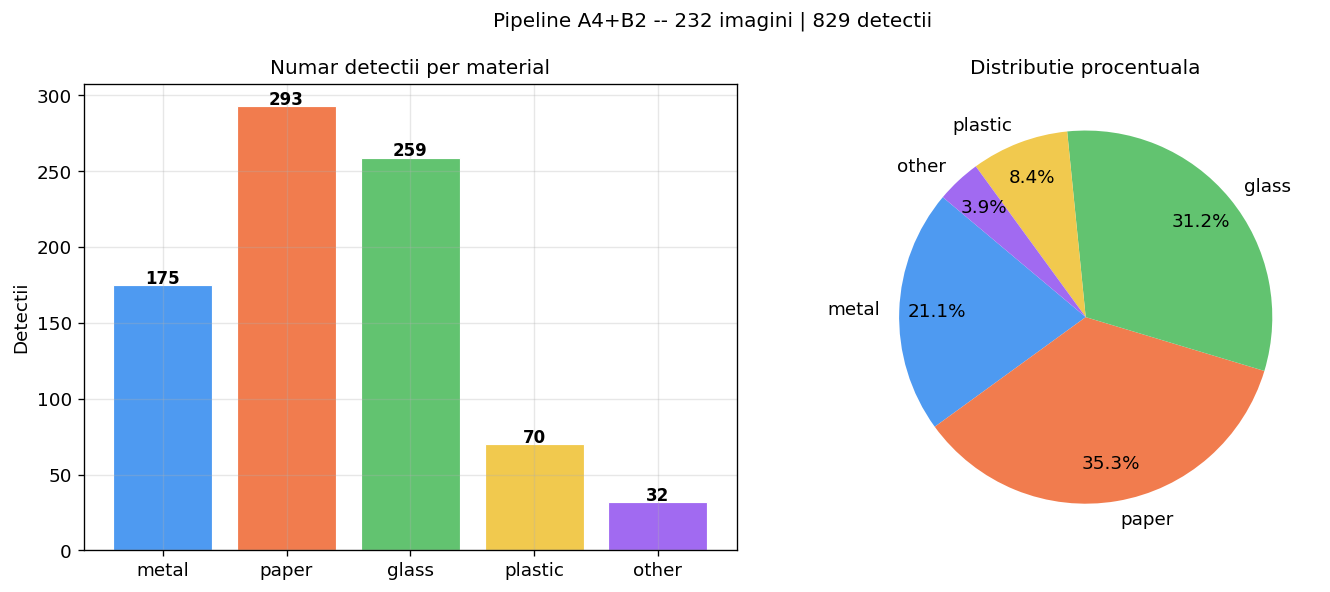

In [7]:
labels=list(material_counter.keys()); values=list(material_counter.values())
colors2=['#4e9af1','#f17c4e','#62c370','#f1c94e','#a16af1']
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,5))
ax1.bar(labels,values,color=colors2[:len(labels)],edgecolor='white',lw=0.7)
ax1.set_title('Numar detectii per material'); ax1.set_ylabel('Detectii')
for i,(l,v) in enumerate(zip(labels,values)):
    ax1.text(i,v+1,str(v),ha='center',fontsize=10,fontweight='bold')
ax2.pie(values,labels=labels,colors=colors2[:len(labels)],autopct='%1.1f%%',
        startangle=140,pctdistance=0.8)
ax2.set_title('Distributie procentuala')
plt.suptitle(f'Pipeline Detector+B2 -- {len(all_dets)} imagini | {total_det} detectii',fontsize=12)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR/'material_distribution.png'),dpi=150,bbox_inches='tight')
plt.show()


---
## 4 - Vizualizare imagini adnotate (top 6 cu detectii)


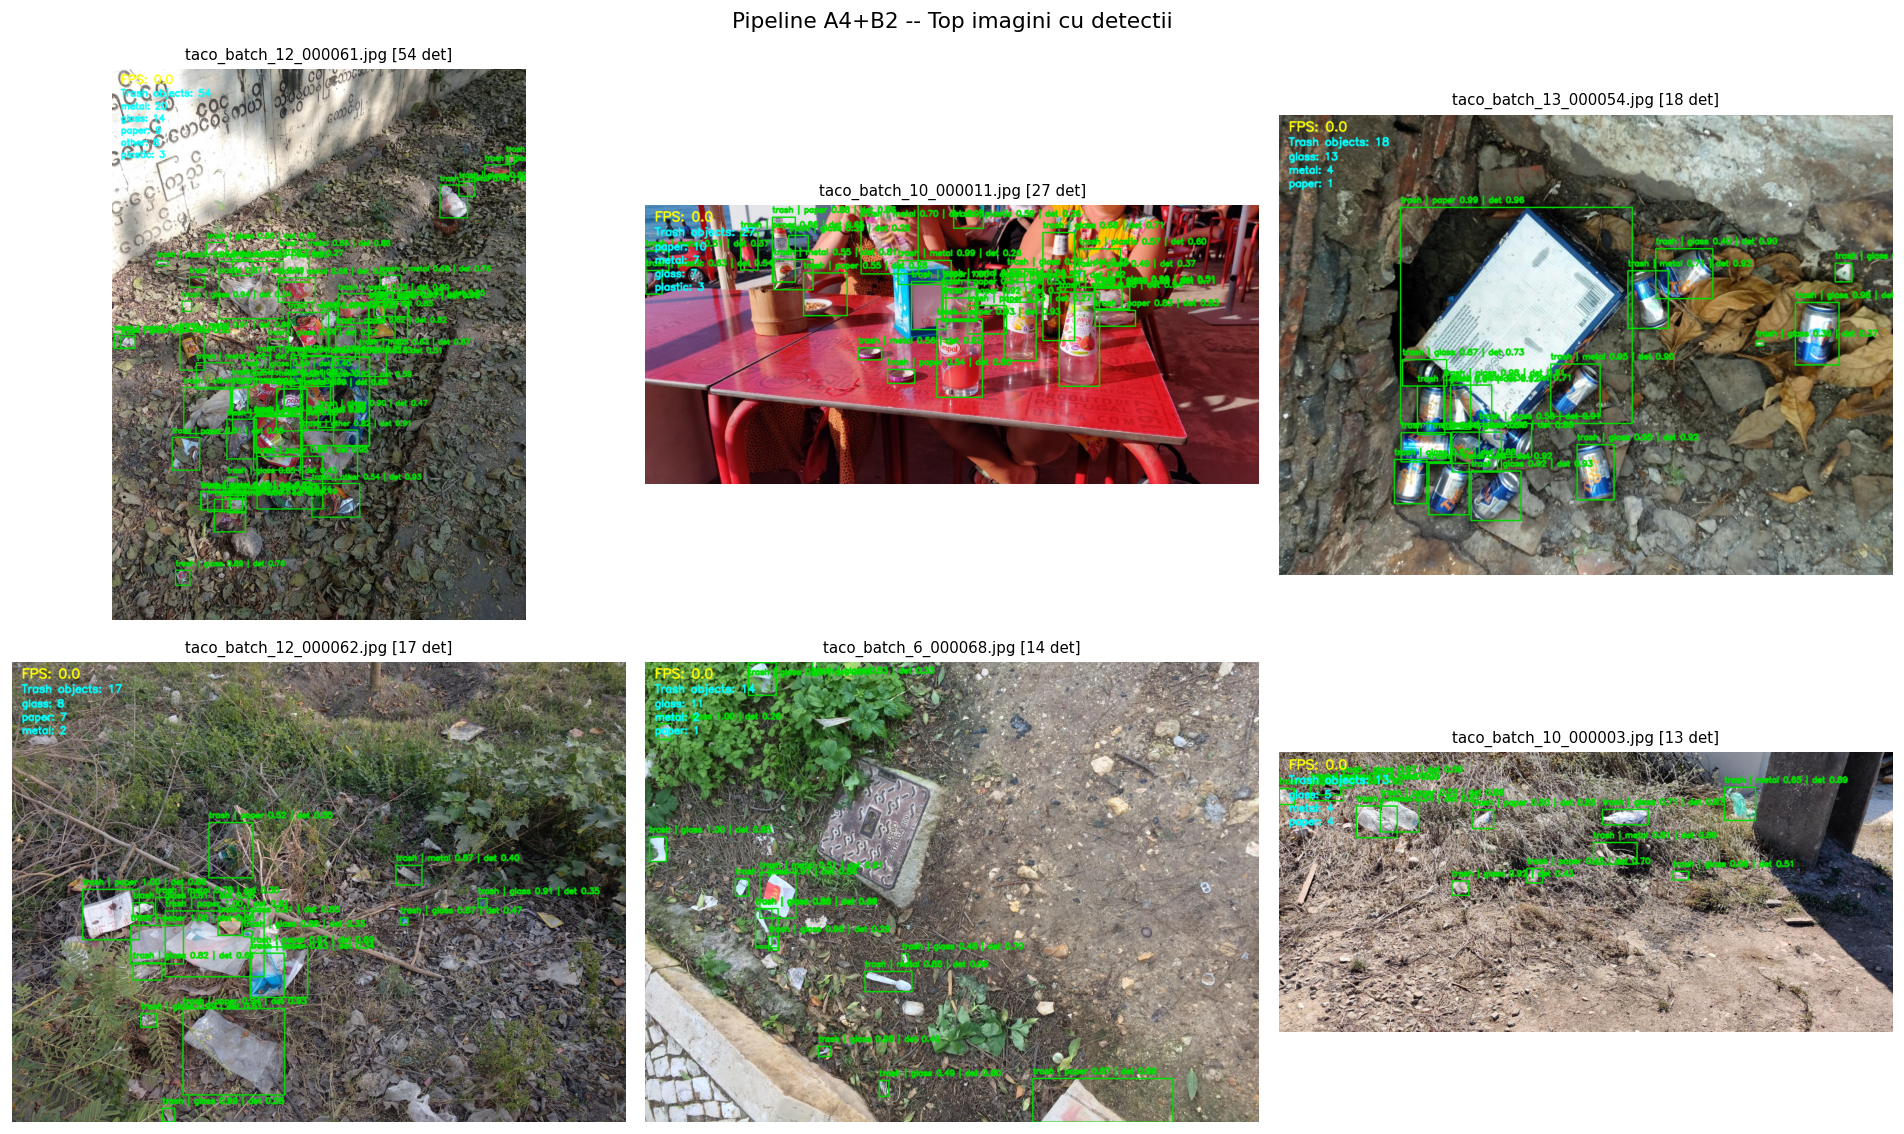

In [8]:
MATERIAL_COLORS={'glass':(78,154,241),'metal':(241,124,78),'other':(98,195,112),
                 'paper':(241,201,78),'plastic':(161,106,241),'unknown':(200,200,200)}
preview=[s for s in all_dets if s[2]]
preview=sorted(preview,key=lambda x:-len(x[2]))[:6]
cols=3; rows_n=2
fig,axes=plt.subplots(rows_n,cols,figsize=(16,10))
axes=np.array(axes).flatten()
for ax,(ip,frame,dets) in zip(axes,preview):
    ann=draw_detections(frame.copy(),dets,fps=0.0,max_labels=5,line_width=2)
    ax.imshow(cv2.cvtColor(ann,cv2.COLOR_BGR2RGB))
    ax.set_title(f'{ip.name} [{len(dets)} det]',fontsize=9)
    ax.axis('off')
for ax in axes[len(preview):]: ax.axis('off')
plt.suptitle('Pipeline Detector+B2 -- Top imagini cu detectii',fontsize=13)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR/'top_detections.png'),dpi=150,bbox_inches='tight')
plt.show()
